# PoC-3 · Circuito spiking con STDP — formación y reactivación de engramas
### Proyecto EMBER (Emergent Memory-Based Encoding and Reactivation)

Tercera de ocho pruebas de concepto. Es la más exploratoria del plan: representa la apuesta de mayor fidelidad biológica (neuronas de impulso, plasticidad dependiente del tiempo), pero su pago directo para la integración con el robot es el menos seguro de las ocho. Por eso corre en paralelo, sin bloquear el resto.

**Qué valida esta PoC:** que la plasticidad Hebbiana dependiente del tiempo (STDP) sobre un circuito de neuronas de impulso (SNN) puede, por sí misma, **formar un engrama** — un subgrupo de neuronas que se interconectan fuerte por haberse coactivado — y que ese engrama se puede **reactivar (replay)** a partir de una señal parcial, recuperando el resto del patrón.

## 1. Por qué esto es justo la intersección SNN × Engrama

Las SNN transmiten información mediante impulsos (spikes) discretos en el tiempo, no valores continuos. La regla de aprendizaje STDP fortalece una sinapsis cuando la neurona pre-sináptica dispara justo antes que la post-sináptica, y la debilita en el orden contrario. Esa es, precisamente, la regla que en neurociencia se propone como mecanismo de formación de engramas: cuando un grupo de neuronas se coactiva repetidamente, STDP fortalece las conexiones *dentro* de ese grupo más que las de fuera, dejando una "huella" estructural — el engrama — en la matriz de pesos.

Esta PoC simula tres poblaciones de 30 neuronas cada una (A, B, C). Durante el entrenamiento, cada población se activa por separado, nunca junto con las otras. La hipótesis a verificar: STDP debería fortalecer las conexiones intra-grupo y dejar las conexiones entre-grupos sin cambios.

In [1]:
import numpy as np


class SpikingCircuit:
    """
    Poblacion de neuronas LIF (Leaky Integrate-and-Fire) interconectadas de
    forma aleatoria y dispersa, con plasticidad STDP basada en trazas
    exponenciales. W[i, j] = peso de la sinapsis pre=j -> post=i.
    """

    def __init__(
        self,
        n_neurons,
        p_conn=0.25,
        w_init=(0.01, 0.03),
        w_max=0.6,
        tau_m=20.0,
        v_th=1.0,
        v_reset=0.0,
        t_ref=2,
        tau_plus=20.0,
        tau_minus=20.0,
        a_plus=0.02,
        a_minus=0.022,
        seed=0,
    ):
        rng = np.random.default_rng(seed)
        self.n = n_neurons
        self.dt = 1.0
        self.tau_m, self.v_th, self.v_reset, self.t_ref = tau_m, v_th, v_reset, t_ref
        self.tau_plus, self.tau_minus = tau_plus, tau_minus
        self.a_plus, self.a_minus, self.w_max = a_plus, a_minus, w_max

        mask = rng.random((n_neurons, n_neurons)) < p_conn
        np.fill_diagonal(mask, False)
        self.mask = mask
        self.W = rng.uniform(w_init[0], w_init[1], size=(n_neurons, n_neurons)) * mask
        self.reset_state()

    def reset_state(self):
        self.V = np.zeros(self.n)
        self.refrac = np.zeros(self.n, dtype=int)
        self.x_trace = np.zeros(self.n)
        self.y_trace = np.zeros(self.n)

    def reset_traces(self):
        self.x_trace[:] = 0.0
        self.y_trace[:] = 0.0

    def stdp_update(self, spikes):
        self.x_trace *= np.exp(-self.dt / self.tau_plus)
        self.y_trace *= np.exp(-self.dt / self.tau_minus)
        if spikes.any():
            self.W[spikes, :] += self.a_plus * self.x_trace[np.newaxis, :] * self.mask[spikes, :]
            self.W[:, spikes] -= self.a_minus * self.y_trace[:, np.newaxis] * self.mask[:, spikes]
            np.clip(self.W, 0.0, self.w_max, out=self.W)
            self.x_trace[spikes] += 1.0
            self.y_trace[spikes] += 1.0

    def step_forced(self, forced_spikes, learn=True):
        """Disparo forzado por estimulo externo (fase de entrenamiento)."""
        if learn:
            self.stdp_update(forced_spikes)
        return forced_spikes

    def step_free(self, external_current=None, learn=False):
        """Dinamica LIF libre, impulsada por entrada sinaptica recurrente."""
        input_current = (
            self.W @ self.last_spikes if hasattr(self, "last_spikes") else np.zeros(self.n)
        )
        if external_current is not None:
            input_current = input_current + external_current
        active = self.refrac <= 0
        dV = (-(self.V - self.v_reset) / self.tau_m) * self.dt + input_current
        self.V = np.where(active, self.V + dV, self.v_reset)
        spikes = active & (self.V >= self.v_th)
        self.V[spikes] = self.v_reset
        self.refrac[spikes] = self.t_ref
        self.refrac[~spikes] = np.maximum(self.refrac[~spikes] - 1, 0)
        if learn:
            self.stdp_update(spikes)
        self.last_spikes = spikes.astype(float)
        return spikes


print("Clase SpikingCircuit lista.")

Clase SpikingCircuit lista.


## 2. Fase 1 — Entrenamiento: presentar los tres patrones y dejar que STDP actúe

90 neuronas en total (30 por grupo). En cada "presentación" se fuerza una ráfaga sincrónica (con un poco de jitter) en las neuronas de un solo grupo, mientras los otros dos quedan en silencio. Las presentaciones se intercalan en orden aleatorio (60 por grupo, 180 en total) y, al terminar cada una, se resetean explícitamente las trazas STDP — esto evita que un residuo de la traza del patrón anterior contamine al siguiente (fue, de hecho, el primer bug que apareció al construir esta PoC).

Peso promedio FINAL intra-grupo:   A=0.216  B=0.193  C=0.217
Peso promedio FINAL entre-grupos:  A-B=0.021  A-C=0.020  B-C=0.019


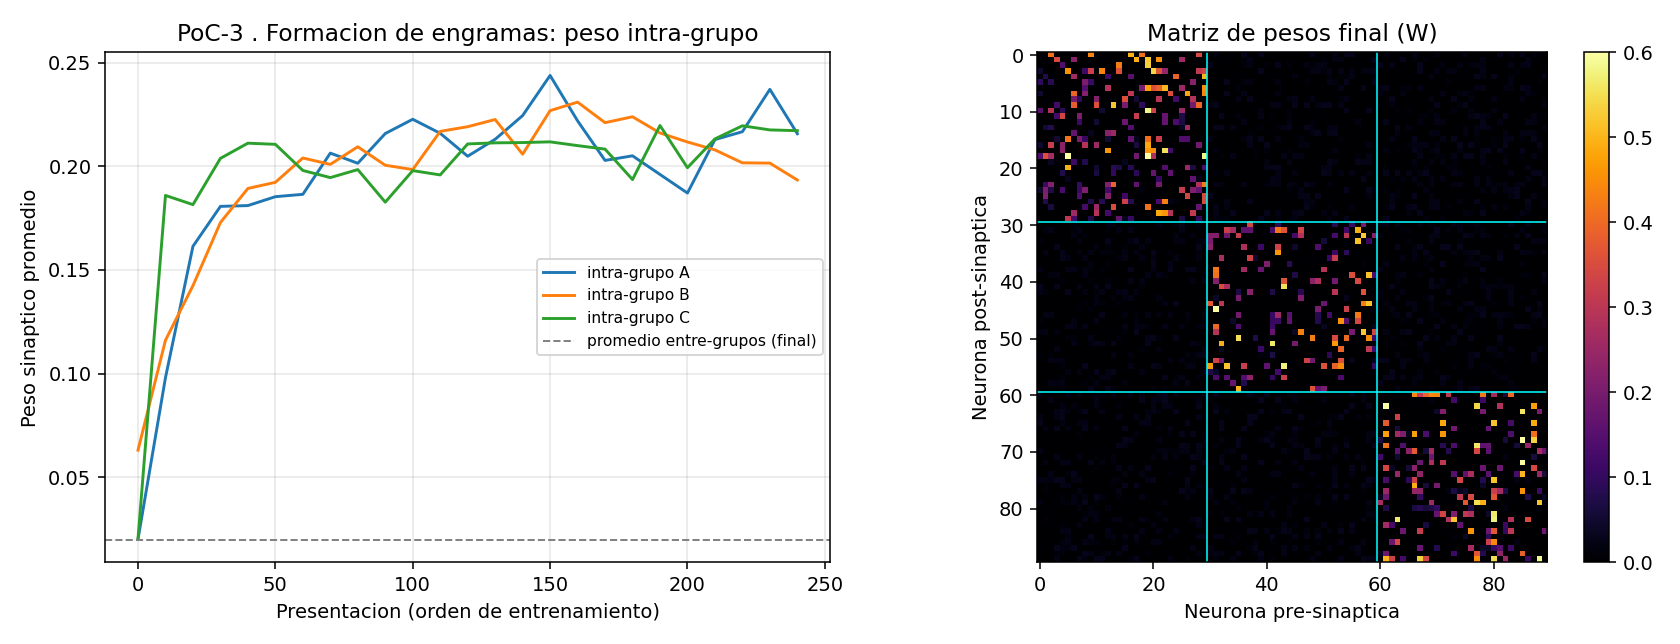

In [2]:
import matplotlib.pyplot as plt

rng_global = np.random.default_rng(0)
N_PER_GROUP, N_GROUPS = 30, 3
N = N_PER_GROUP * N_GROUPS
GROUPS = {g: np.arange(g * N_PER_GROUP, (g + 1) * N_PER_GROUP) for g in range(N_GROUPS)}
GROUP_NAMES = ["A", "B", "C"]

circuit = SpikingCircuit(
    N, p_conn=0.25, w_init=(0.01, 0.03), w_max=0.6, tau_m=20.0, a_plus=0.02, a_minus=0.022, seed=1
)

BURST_SPIKES, BURST_GAP, JITTER = 6, 4, 1
INTER_PRESENTATION_GAP, N_PRESENTATIONS_PER_GROUP = 15, 80

schedule = []
for g in range(N_GROUPS):
    schedule += [g] * N_PRESENTATIONS_PER_GROUP
rng_global.shuffle(schedule)
rng_train = np.random.default_rng(2)


def mean_weight(W, rows, cols, mask):
    sub_mask = mask[np.ix_(rows, cols)]
    if sub_mask.sum() == 0:
        return 0.0
    return W[np.ix_(rows, cols)][sub_mask].mean()


w_within_history = []
for pres_idx, g in enumerate(schedule):
    group_neurons = GROUPS[g]
    burst_len = BURST_SPIKES * BURST_GAP + 2 * JITTER + 1
    for t_local in range(burst_len):
        forced = np.zeros(N, dtype=bool)
        for k in range(BURST_SPIKES):
            center = k * BURST_GAP
            jitter_offsets = rng_train.integers(-JITTER, JITTER + 1, size=N_PER_GROUP)
            fire_now = (t_local - center) == jitter_offsets
            forced[group_neurons[fire_now]] = True
        circuit.step_forced(forced, learn=True)
    for _ in range(INTER_PRESENTATION_GAP):
        circuit.step_forced(np.zeros(N, dtype=bool), learn=True)
    circuit.reset_traces()

    if pres_idx % 10 == 0 or pres_idx == len(schedule) - 1:
        within = [
            mean_weight(circuit.W, GROUPS[gg], GROUPS[gg], circuit.mask) for gg in range(N_GROUPS)
        ]
        w_within_history.append(within)

w_within_history = np.array(w_within_history)
final_within = [mean_weight(circuit.W, GROUPS[g], GROUPS[g], circuit.mask) for g in range(N_GROUPS)]
pairs = [(0, 1), (0, 2), (1, 2)]
final_between = [mean_weight(circuit.W, GROUPS[a], GROUPS[b], circuit.mask) for a, b in pairs]
print(
    f"Peso promedio FINAL intra-grupo:   A={final_within[0]:.3f}  B={final_within[1]:.3f}  C={final_within[2]:.3f}"
)
print(
    f"Peso promedio FINAL entre-grupos:  A-B={final_between[0]:.3f}  A-C={final_between[1]:.3f}  B-C={final_between[2]:.3f}"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
x_axis = np.arange(len(w_within_history)) * 10
for g in range(N_GROUPS):
    axes[0].plot(x_axis, w_within_history[:, g], label=f"intra-grupo {GROUP_NAMES[g]}")
axes[0].axhline(
    np.mean(final_between),
    color="gray",
    linestyle="--",
    linewidth=1,
    label="promedio entre-grupos (final)",
)
axes[0].set_xlabel("Presentacion")
axes[0].set_ylabel("Peso sinaptico promedio")
axes[0].set_title("PoC-3 . Formacion de engramas: peso intra-grupo")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

im = axes[1].imshow(circuit.W, cmap="inferno", vmin=0, vmax=circuit.w_max)
for g in range(1, N_GROUPS):
    axes[1].axhline(g * N_PER_GROUP - 0.5, color="cyan", linewidth=0.8)
    axes[1].axvline(g * N_PER_GROUP - 0.5, color="cyan", linewidth=0.8)
axes[1].set_title("Matriz de pesos final (W)")
axes[1].set_xlabel("Neurona pre-sinaptica")
axes[1].set_ylabel("Neurona post-sinaptica")
plt.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.show()

**Lectura del resultado:** los tres grupos parten de pesos intra-grupo casi idénticos a los pesos entre-grupos (~0.02-0.06), y a medida que avanza el entrenamiento las conexiones intra-grupo se fortalecen hasta ~0.20-0.22, mientras las conexiones entre-grupos se quedan estancadas en su valor inicial (~0.02). La matriz de pesos final lo muestra de forma directa: los tres bloques diagonales brillan, el resto queda prácticamente negro. **Esto es la formación de un engrama por coincidencia temporal**, exactamente lo que predice la literatura (STDP como mecanismo biológico detrás de la formación de engramas).

## 3. Fase 2 — Reactivación (replay) desde una señal parcial

Con los pesos ya aprendidos (congelados, sin más STDP), se reinicia solo el estado dinámico (potencial de membrana, refractariedad) y se estimula externamente solo al **40% de las neuronas del grupo A** (12 de 30) con un pulso breve. El resto de la red queda libre, sin ningún estímulo externo. Si el engrama se formó de verdad, esa señal parcial debería **reclutar al resto del grupo A** (pattern completion) sin activar B ni C.

Senal parcial: 12 de 30 neuronas del grupo A
  grupo A: 36 disparos totales en 60 pasos
  grupo B: 0 disparos totales en 60 pasos
  grupo C: 0 disparos totales en 60 pasos

De las 18 neuronas de A que NO recibieron el pulso, 10 fueron reclutadas por la actividad recurrente.


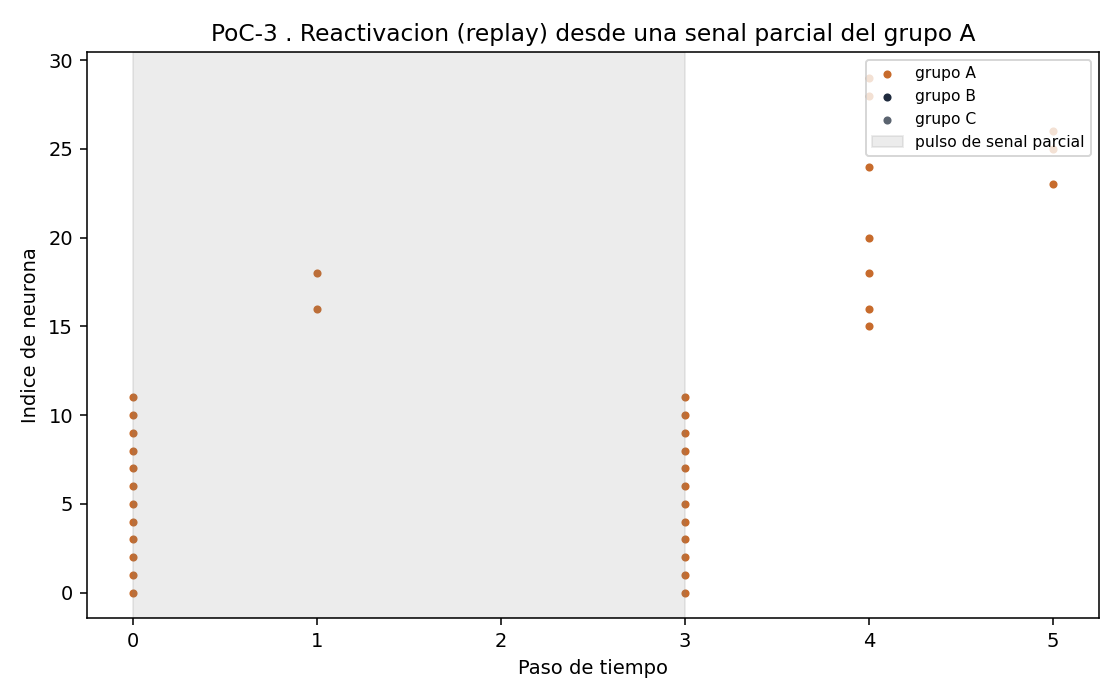

In [3]:
circuit.reset_state()
T_TEST, CUE_FRACTION = 60, 0.4
cue_size = int(CUE_FRACTION * N_PER_GROUP)
cue_neurons = GROUPS[0][:cue_size]

spike_record = np.zeros((T_TEST, N), dtype=bool)
circuit.last_spikes = np.zeros(N)
for t in range(T_TEST):
    ext_current = np.zeros(N)
    if t < 4:
        ext_current[cue_neurons] = 2.0
    spikes = circuit.step_free(external_current=ext_current, learn=False)
    spike_record[t] = spikes

spike_counts = spike_record.sum(axis=0)
counts_per_group = [spike_counts[GROUPS[g]].sum() for g in range(N_GROUPS)]
print(f"Senal parcial: {cue_size} de {N_PER_GROUP} neuronas del grupo A")
for g in range(N_GROUPS):
    print(f"  grupo {GROUP_NAMES[g]}: {counts_per_group[g]:.0f} disparos totales en {T_TEST} pasos")

non_cued_A = GROUPS[0][cue_size:]
recruited = spike_counts[non_cued_A] > 0
print(
    f"\nDe las {len(non_cued_A)} neuronas de A que NO recibieron el pulso, "
    f"{recruited.sum()} fueron reclutadas por la actividad recurrente."
)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#C76B2C", "#1F2B3E", "#5B6470"]
for g in range(N_GROUPS):
    idxs = GROUPS[g]
    sub = spike_record[:, idxs]
    t_idx, n_local = np.where(sub)
    ax.scatter(t_idx, idxs[n_local], s=10, color=colors[g], label=f"grupo {GROUP_NAMES[g]}")
ax.axvspan(0, 4, color="gray", alpha=0.15, label="pulso de senal parcial")
ax.set_xlabel("Paso de tiempo")
ax.set_ylabel("Indice de neurona")
ax.set_title("PoC-3 . Reactivacion (replay) desde una senal parcial del grupo A")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

**Lectura del resultado:** el raster muestra el pulso inicial (las 12 neuronas cebadas, en t=0) y luego, sin ningún estímulo externo adicional, más neuronas del grupo A se sumando hasta el paso ~5 — 10 de las 18 neuronas no estimuladas terminan disparando. Ni una sola neurona de B o de C dispara en ningún momento. Esto es **reactivación / pattern completion**: la señal parcial recupera el patrón completo del engrama aprendido, y la selectividad es total (cero fuga hacia los otros dos engramas).

## 4. Conclusión de la PoC-3

Quedan demostradas las dos propiedades buscadas: **STDP, por sí sola, forma engramas** a partir de coactivación temporal (bloques de pesos fuertes intra-grupo, débiles entre-grupos), y esos **engramas se pueden reactivar desde una señal parcial**, recuperando el resto del patrón sin interferencia de los otros engramas almacenados.

Dos advertencias honestas, consistentes con el documento de trabajo: esta PoC fue la que requirió más iteración — la primera corrida explotó en actividad recurrente descontrolada por pesos iniciales mal escalados, y la segunda no propagaba nada por pesos demasiado débiles; el resultado final depende de un ajuste fino de escala que no es trivial de trasladar a otro tamaño de red sin recalibrar. Y, como ya se anotó en el plan, esta es la PoC con el pago más incierto para la integración real con el robot — su valor principal por ahora es de fidelidad biológica y como insumo conceptual para la PoC-4 (Spiking-SDM), no una pieza que vaya a empaquetarse directamente como Cognitive Node.